# Этап 1: Подготовка данных и нарезка патчей
В этом разделе мы загружаем датасет BCCD, создаем структуру папок и извлекаем фрагменты клеток и фона для будущего генератора.

In [103]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import shutil
import kagglehub

shutil.rmtree('patches', ignore_errors=True)
os.makedirs('patches/cells', exist_ok=True)
os.makedirs('patches/background', exist_ok=True)

print('Загрузка датасета...')
path = kagglehub.dataset_download('jeetblahiri/bccd-dataset-with-mask')
print('Путь к файлам датасета:', path)

DATASET_PATH = path

Загрузка датасета...
Using Colab cache for faster access to the 'bccd-dataset-with-mask' dataset.
Путь к файлам датасета: /kaggle/input/bccd-dataset-with-mask


In [87]:
def extract_and_save_patches(data_path):
    # Поиск всех изображений и масок
    img_files = sorted(glob(os.path.join(data_path, '**/*.jpg'), recursive=True))
    mask_files = sorted(glob(os.path.join(data_path, '**/*.png'), recursive=True))

    print(f'Найдено изображений: {len(img_files)}, масок: {len(mask_files)}')

    cell_count = 0
    bg_count = 0

    # Нарезаем патчи из ВСЕХ найденных изображений
    for img_p in tqdm(img_files, desc='Нарезка всех патчей'):
        # Ищем соответствующую маску
        base_name = os.path.basename(img_p).split('.')[0]
        mask_p = next((m for m in mask_files if base_name in m), None)

        if mask_p:
            img = cv2.imread(img_p)
            mask = cv2.imread(mask_p, 0)
            if img is None or mask is None: continue

            # Извлечение клеток
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)
                if w > 15 and h > 15:
                    cell = img[y:y+h, x:x+w]
                    cv2.imwrite(f'patches/cells/cell_{cell_count}.png', cell)
                    cell_count += 1

            # Извлечение фона
            for _ in range(5): # Уменьшим до 5 на картинку, так как картинок много
                ry, rx = np.random.randint(0, img.shape[0]-64), np.random.randint(0, img.shape[1]-64)
                # Проверка, что область пустая
                if np.mean(mask[ry:ry+64, rx:rx+64]) < 2:
                    bg = img[ry:ry+64, rx:rx+64]
                    cv2.imwrite(f'patches/background/bg_{bg_count}.png', bg)
                    bg_count += 1

    print(f'\nГотово! Обработано все изображения. Сохранено клеток: {cell_count}, патчей фона: {bg_count}')

extract_and_save_patches(DATASET_PATH)

Найдено изображений: 119, масок: 2537


Нарезка всех патчей: 100%|██████████| 119/119 [00:10<00:00, 11.13it/s]


Готово! Обработано все изображения. Сохранено клеток: 6893, патчей фона: 320


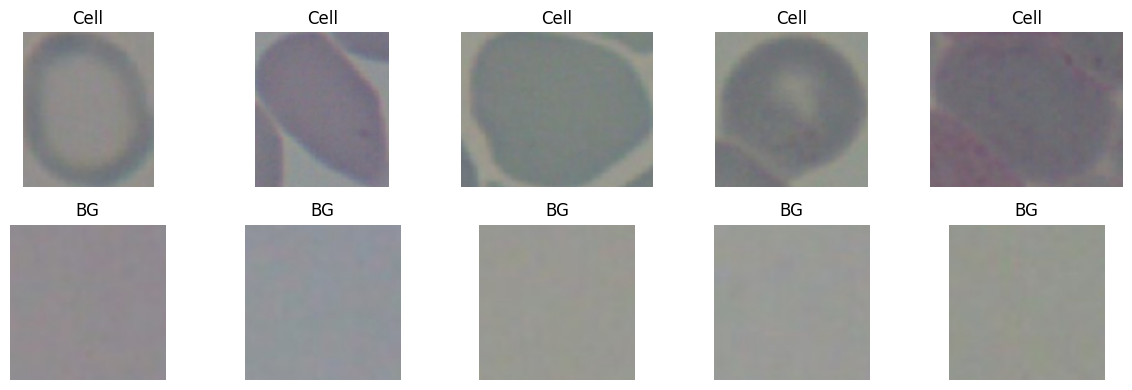

In [88]:
# Визуализация нарезанных данных
def show_extracted_patches():
    cell_samples = glob('patches/cells/*.png')[:5]
    bg_samples = glob('patches/background/*.png')[:5]

    if not cell_samples or not bg_samples:
        print('Патчи не найдены. Проверьте этап нарезки.')
        return

    plt.figure(figsize=(12, 4))
    for i, path in enumerate(cell_samples):
        plt.subplot(2, 5, i+1)
        plt.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
        plt.title('Cell')
        plt.axis('off')

    for i, path in enumerate(bg_samples):
        plt.subplot(2, 5, i+6)
        plt.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
        plt.title('BG')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_extracted_patches()

# Этап 2: Генератор снимков клеток крови
На этом этапе мы объединяем фон и объекты, используя алгоритмы бесшовного клонирования.

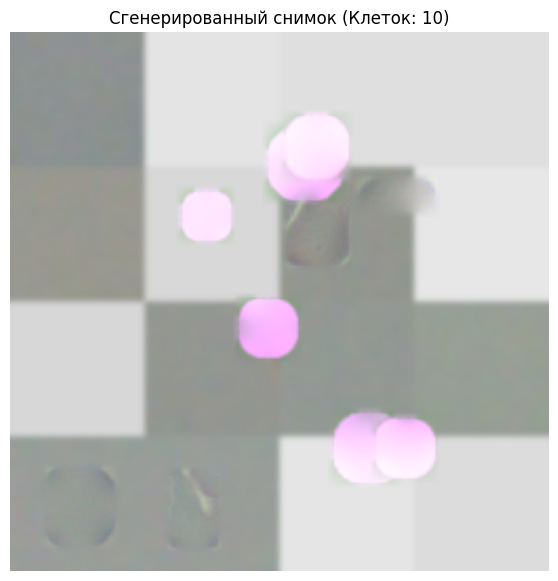

In [97]:
import random

class AdvancedBloodCellGenerator:
    def __init__(self, cell_dir, bg_dir, size=(256, 256)):
        self.cell_files = glob(os.path.join(cell_dir, '*.png'))
        self.bg_files = glob(os.path.join(bg_dir, '*.png'))
        self.size = size

    def create_background(self):
        bg = np.zeros((self.size[1], self.size[0], 3), dtype=np.uint8)
        p_size = 64
        for i in range(0, self.size[1], p_size):
            for j in range(0, self.size[0], p_size):
                if random.random() > 0.4 and self.bg_files:
                    p = cv2.imread(random.choice(self.bg_files))
                    p = cv2.resize(p, (p_size, p_size))
                else:
                    # Равномерная заливка
                    color = random.randint(215, 235)
                    p = np.full((p_size, p_size, 3), color, dtype=np.uint8)
                bg[i:i+p_size, j:j+p_size] = p
        return cv2.GaussianBlur(bg, (7, 7), 0)

    def generate_image(self):
        img = self.create_background()
        num_cells = random.randint(10, 25)

        for _ in range(num_cells):
            if random.random() > 0.5 and self.cell_files:
                cell = cv2.imread(random.choice(self.cell_files))
                h, w = cell.shape[:2]
                if h > 55 or w > 55:
                    s = 45 / max(h, w)
                    cell = cv2.resize(cell, (0,0), fx=s, fy=s)
            else:
                # Искусственная клетка (круг)
                c_s = random.randint(30, 45)
                cell = np.zeros((c_s, c_s, 3), dtype=np.uint8)
                color = (random.randint(130, 170), 30, random.randint(110, 150))
                cv2.circle(cell, (c_s//2, c_s//2), c_s//2 - 3, color, -1)
                cell = cv2.GaussianBlur(cell, (3, 3), 0)

            h, w = cell.shape[:2]
            try:
                cx = random.randint(w//2+1, self.size[0]-w//2-1)
                cy = random.randint(h//2+1, self.size[1]-h//2-1)
                mask = np.full(cell.shape, 255, cell.dtype)
                img = cv2.seamlessClone(cell, img, mask, (cx, cy), cv2.NORMAL_CLONE)
            except: continue

        return img, num_cells

gen = AdvancedBloodCellGenerator('patches/cells', 'patches/background')
clean_img, count = gen.generate_image()

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB))
plt.title(f'Сгенерированный снимок (Клеток: {count})')
plt.axis('off')
plt.show()

# Этап 3: Пост-процессинг, наложение шума и бенчмарк
Реализация функций зашумления и оценка эффективности различных алгоритмов фильтрации на 100 выборках.

In [99]:
def add_noise(img, noise_type='gaussian'):
    """
    Накладывает шум Гаусса или равномерный шум на изображение.
    """
    if noise_type == 'gaussian':
        noise = np.random.normal(0, 20, img.shape).astype(np.float32)
    else: # uniform
        noise = np.random.uniform(-25, 25, img.shape).astype(np.float32)

    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def apply_filters(img, method='median', param=5):
    """
    Применяет различные алгоритмы фильтрации для удаления шума.
    """
    if method == 'median':
        return cv2.medianBlur(img, param)
    elif method == 'gaussian':
        return cv2.GaussianBlur(img, (param, param), 0)
    elif method == 'bilateral':
        return cv2.bilateralFilter(img, 9, param*10, param*10)
    elif method == 'nlm':
        # fastNlMeansDenoisingColored(src, dst, h, hColor, templateWindowSize, searchWindowSize)
        return cv2.fastNlMeansDenoisingColored(img, None, param, param, 7, 21)
    return img

In [100]:
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

# Параметры бенчмарка
n_samples = 100
methods = ['median', 'gaussian', 'bilateral', 'nlm']
noise_types = ['gaussian', 'uniform']

# Инициализация результатов
results = {nt: {m: {'ssim': [], 'mse': []} for m in methods} for nt in noise_types}

print('Запуск бенчмарка на 100 изображениях...')
for _ in tqdm(range(n_samples), desc='Бенчмарк'):
    # Генератор возвращает изображение без шума и количество клеток
    clean, _ = gen.generate_image()

    for nt in noise_types:
        # 1. Наложение шума (Гаусс или Равномерный)
        noisy = add_noise(clean, nt)

        for m in methods:
            # 2. Очистка шума (подбор параметров: p=5 для стандартных, p=10 для NLM)
            param = 5 if m != 'nlm' else 10
            denoised = apply_filters(noisy, m, param)

            # 3. Расчет метрик качества
            results[nt][m]['ssim'].append(ssim(clean, denoised, channel_axis=2))
            results[nt][m]['mse'].append(np.mean((clean.astype(float) - denoised.astype(float))**2))

# Вывод итогового анализа
print('\n' + '='*50)
for nt in noise_types:
    print(f'Результаты для типа шума: {nt.upper()}')
    best_ssim = -1
    best_method = ''
    for m in methods:
        s_mean = np.mean(results[nt][m]['ssim'])
        e_mean = np.mean(results[nt][m]['mse'])
        print(f'Метод: {m:10} | SSIM: {s_mean:.4f} | MSE: {e_mean:.2f}')
        if s_mean > best_ssim:
            best_ssim = s_mean
            best_method = m
    print(f'>> ЛУЧШИЙ АЛГОРИТМ ДЛЯ {nt.upper()}: {best_method.upper()}\n')

Запуск бенчмарка на 100 изображениях...


Бенчмарк: 100%|██████████| 100/100 [00:43<00:00,  2.31it/s]


Результаты для типа шума: GAUSSIAN
Метод: median     | SSIM: 0.7972 | MSE: 32.39
Метод: gaussian   | SSIM: 0.7684 | MSE: 36.34
Метод: bilateral  | SSIM: 0.6814 | MSE: 49.39
Метод: nlm        | SSIM: 0.9253 | MSE: 29.94
>> ЛУЧШИЙ АЛГОРИТМ ДЛЯ GAUSSIAN: NLM

Результаты для типа шума: UNIFORM
Метод: median     | SSIM: 0.8075 | MSE: 29.36
Метод: gaussian   | SSIM: 0.8506 | MSE: 21.85
Метод: bilateral  | SSIM: 0.8599 | MSE: 20.00
Метод: nlm        | SSIM: 0.9320 | MSE: 27.10
>> ЛУЧШИЙ АЛГОРИТМ ДЛЯ UNIFORM: NLM



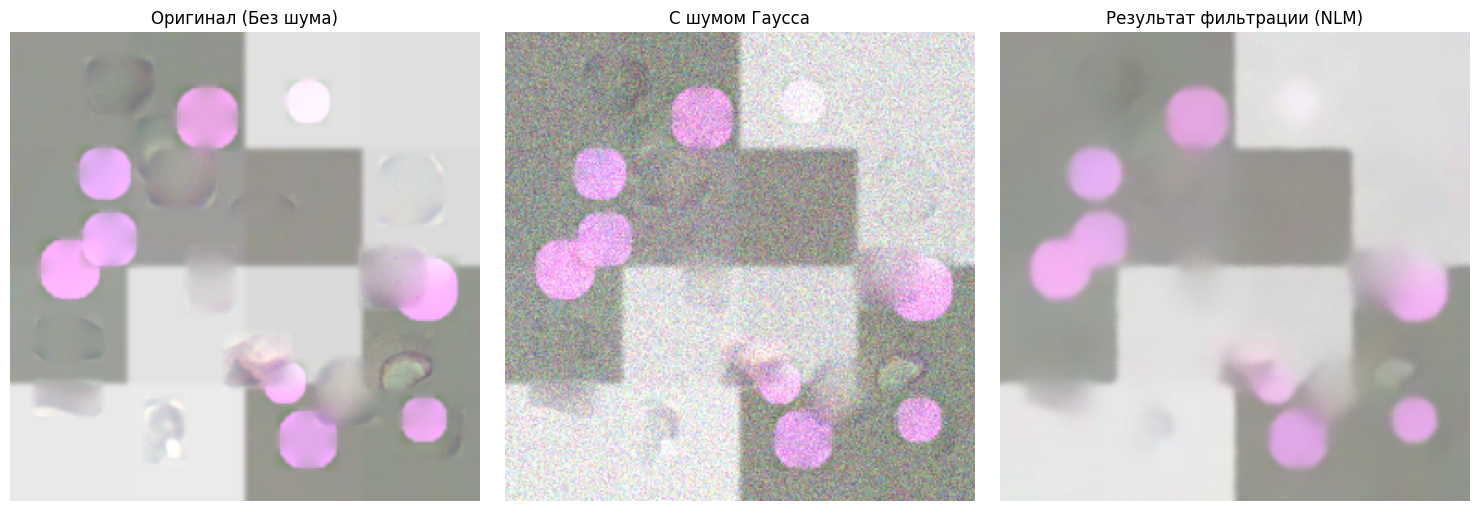

In [102]:
# Визуализация одного примера процесса
img_clean, _ = gen.generate_image()
img_noisy = add_noise(img_clean, 'gaussian')
img_denoised = apply_filters(img_noisy, 'nlm', 10)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_clean, cv2.COLOR_BGR2RGB))
plt.title('Оригинал (Без шума)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_noisy, cv2.COLOR_BGR2RGB))
plt.title('С шумом Гаусса')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_denoised, cv2.COLOR_BGR2RGB))
plt.title('Результат фильтрации (NLM)')
plt.axis('off')

plt.tight_layout()
plt.show()